# DataAnalysis_LittleSteps

## LittleSteps Operational Analytics Assignment

This notebook performs the complete analysis on the processed LittleSteps visit dataset.

The objective is to analyse patient visit durations, nurse travel/transition durations, location-based differences, nurse-level travel patterns, and insights extracted from nurse notes. The notebook also generates visualisations and saves them into a `plots` folder for use in the final report and GitHub submission.

## 1. Analysis Objectives

The analysis is designed to answer the core questions from the assignment:

1. Determine the average visit and travel duration across all service types.
2. Analyse how average visit duration changes by `service_type` and identify the longest and shortest service types.
3. Investigate whether visit durations differ across `visit_location` zones.
4. Identify the top 3 and bottom 3 nurses by average travel duration.
5. Infer insights from `nurse_notes` regarding visit outcomes or patient needs that may influence visit duration.
6. Propose suggestions for improving operational efficiency based on the analysis.

The dataset used in this notebook is the processed dataset generated from the data preparation stage.

## 2. Import Libraries and Configure Settings

The following libraries are used for data manipulation, statistical analysis, and visualisation.

Only commonly used Python libraries are used so the notebook can run easily in a local environment.

In [1]:
# Core data analysis libraries
import pandas as pd
import numpy as np

# Visualisation libraries
import matplotlib.pyplot as plt

# File and folder management
from pathlib import Path

# Optional statistical testing
try:
    from scipy import stats
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# Create folder for saving plots
plots_dir = Path("plots")
plots_dir.mkdir(exist_ok=True)

print("Libraries imported successfully.")
print(f"SciPy available: {SCIPY_AVAILABLE}")

Libraries imported successfully.
SciPy available: True


## 3. Load the Processed Dataset

The code below tries multiple common file paths so that the notebook can run whether it is opened from the repository root folder or from inside the `Data Analysis` folder.

Update the path manually if your local folder structure is different.

In [2]:
# Possible file paths for the processed dataset
possible_paths = [
    Path("visits_processed.csv"),
    Path("Datasets/visits_processed.csv"),
    Path("../Datasets/visits_processed.csv"),
    Path("data/visits_processed.csv"),
    Path("../data/visits_processed.csv")
]

# Find the first existing path
data_path = None
for path in possible_paths:
    if path.exists():
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError(
        "Could not find visits_processed.csv. Please update the data_path variable manually."
    )

# Load processed dataset
visits = pd.read_csv(data_path)

print(f"Dataset loaded from: {data_path}")
print(f"Dataset shape: {visits.shape[0]} rows and {visits.shape[1]} columns")

visits.head()

Dataset loaded from: ..\Datasets\visits_processed.csv
Dataset shape: 878 rows and 25 columns


,visit_id,patient_id,nurse_id,visit_start_time,visit_end_time,service_type,visit_location,nurse_notes,visit_duration_original_minutes,is_visit_duration_outlier,visit_duration_minutes,previous_visit_end_time,previous_visit_location,travel_duration_minutes,changed_location_from_previous_visit,nurse_notes_clean,note_mentions_urgent,note_mentions_follow_up,note_mentions_pain,note_mentions_weakness_or_dizziness,note_mentions_stable_or_improving,note_mentions_medication,note_mentions_wound_care,note_mentions_mobility_support,note_outcome_category
0,a7c0d48c-26d5-47f4-a5c6-97b93fb08c0b,P60703,N1066,2025-08-20 20:30:41,2025-08-20 21:42:41,Medication Administration,East,No notes provided,72.0,False,72.0,NaN,NaN,NaN,NaN,no notes provided,0,0,0,0,0,0,0,0,No Notes Provided
1,ec09fa84-50de-4670-91f1-83a2b290f1cb,P89830,N1066,2025-08-26 06:00:49,2025-08-26 06:01:49,Medication Administration,North,Follow-up is required. The nurse delivered the...,1.0,False,1.0,2025-08-20 21:42:41,East,7698.133333,1.0,follow-up is required the nurse delivered the ...,0,1,0,0,1,0,0,0,Follow-up / Review Required
2,b64afacd-cb51-40c3-bb57-e054ae3ea082,P76027,N1066,2025-09-06 17:45:30,2025-09-06 18:31:30,Physical Therapy,South,Monitoring is required. The nurse encouraged t...,46.0,False,46.0,2025-08-26 06:01:49,North,16543.683333,1.0,monitoring is required the nurse encouraged th...,0,1,0,1,0,0,0,0,Follow-up / Review Required
3,4d217cf0-d5bf-4c54-9072-9ac0ada81d1f,P35198,N1066,2025-09-06 20:23:00,2025-09-06 21:02:00,General Check-up,East,The nurse checked the oxygen level. The patien...,39.0,False,39.0,2025-09-06 18:31:30,South,111.500000,1.0,the nurse checked the oxygen level the patient...,0,0,0,0,1,0,0,0,Stable / Improving
4,1055d02d-3484-430b-bfb2-b59fc9431683,P60246,N1066,2025-09-07 19:42:23,2025-09-07 20:53:23,Wound Care,South,The nurse changed the bandage. The patient is ...,71.0,False,71.0,2025-09-06 21:02:00,East,1360.383333,1.0,the nurse changed the bandage the patient is i...,1,1,1,0,0,0,1,0,Urgent / Critical Attention


## 4. Data Type Review and Final Preparation

Although the dataset has already been processed, the datetime fields are converted again after loading because CSV files do not preserve datetime data types automatically.

This ensures that time-based calculations and validations work correctly in the analysis notebook.

In [3]:
# Convert relevant datetime columns after loading from CSV
datetime_columns = [
    'visit_start_time',
    'visit_end_time',
    'previous_visit_end_time'
]

for col in datetime_columns:
    if col in visits.columns:
        visits[col] = pd.to_datetime(visits[col], errors='coerce')

# Review data types
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 878 entries, 0 to 877
Data columns (total 25 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   visit_id                              878 non-null    object        
 1   patient_id                            878 non-null    object        
 2   nurse_id                              878 non-null    object        
 3   visit_start_time                      878 non-null    datetime64[ns]
 4   visit_end_time                        878 non-null    datetime64[ns]
 5   service_type                          878 non-null    object        
 6   visit_location                        878 non-null    object        
 7   nurse_notes                           878 non-null    object        
 8   visit_duration_original_minutes       878 non-null    float64       
 9   is_visit_duration_outlier             878 non-null    bool          
 10  vi

## 5. Dataset Overview

This section provides a high-level overview of the processed dataset, including record counts, unique patients, unique nurses, service types, and visit locations.

In [4]:
overview = {
    "Total records": len(visits),
    "Unique visits": visits['visit_id'].nunique() if 'visit_id' in visits.columns else np.nan,
    "Unique patients": visits['patient_id'].nunique() if 'patient_id' in visits.columns else np.nan,
    "Unique nurses": visits['nurse_id'].nunique() if 'nurse_id' in visits.columns else np.nan,
    "Service types": visits['service_type'].nunique() if 'service_type' in visits.columns else np.nan,
    "Visit locations": visits['visit_location'].nunique() if 'visit_location' in visits.columns else np.nan,
    "Earliest visit": visits['visit_start_time'].min() if 'visit_start_time' in visits.columns else np.nan,
    "Latest visit": visits['visit_start_time'].max() if 'visit_start_time' in visits.columns else np.nan
}

overview_df = pd.DataFrame(list(overview.items()), columns=["Metric", "Value"])
overview_df

,Metric,Value
0,Total records,878
1,Unique visits,878
2,Unique patients,415
3,Unique nurses,100
4,Service types,4
5,Visit locations,4
6,Earliest visit,2025-08-19 12:19:00
7,Latest visit,2025-09-18 11:34:02


## 6. Travel Duration Interpretation

The processed dataset contains `travel_duration_minutes`, which was estimated as the time gap between the previous visit end time and the current visit start time for the same nurse.

However, this value is a **proxy** and not actual travel time. If two visits are separated by overnight gaps or multiple days, the raw value would incorrectly include non-travel periods.

Therefore, this notebook creates a more conservative analysis variable called `valid_travel_duration_minutes`.

### Rule Used

A travel duration is considered valid for analysis only if:

- The current and previous visit occurred on the same calendar day.
- The travel duration is non-negative.
- The travel duration is not excessively high.

For this analysis, a threshold of 240 minutes is used as a practical upper limit. Any gap above this is treated as a long operational break rather than travel time.

In [5]:
# Create date columns for same-day validation
visits['visit_date'] = visits['visit_start_time'].dt.date
visits['previous_visit_date'] = visits['previous_visit_end_time'].dt.date

# Same-day flag
visits['same_day_as_previous_visit'] = visits['visit_date'] == visits['previous_visit_date']

# Create a cleaner travel duration metric for analysis
visits['valid_travel_duration_minutes'] = visits['travel_duration_minutes']

# Remove travel values where previous visit was not on the same day
visits.loc[~visits['same_day_as_previous_visit'], 'valid_travel_duration_minutes'] = np.nan

# Remove negative or unrealistic transition gaps
visits.loc[visits['valid_travel_duration_minutes'] < 0, 'valid_travel_duration_minutes'] = np.nan
visits.loc[visits['valid_travel_duration_minutes'] > 240, 'valid_travel_duration_minutes'] = np.nan

travel_validation_summary = pd.DataFrame({
    "Metric": [
        "Raw travel duration records",
        "Valid same-day travel records",
        "Excluded travel records"
    ],
    "Count": [
        visits['travel_duration_minutes'].notna().sum(),
        visits['valid_travel_duration_minutes'].notna().sum(),
        visits['travel_duration_minutes'].notna().sum() - visits['valid_travel_duration_minutes'].notna().sum()
    ]
})

travel_validation_summary

,Metric,Count
0,Raw travel duration records,762
1,Valid same-day travel records,29
2,Excluded travel records,733


## 7. Descriptive Statistics

This section calculates descriptive statistics for both visit duration and valid travel duration.

The visit duration represents the time spent during the patient visit, while the valid travel duration represents a filtered proxy for nurse transition time between same-day visits.

In [6]:
duration_summary = visits[['visit_duration_minutes', 'valid_travel_duration_minutes']].describe().T
duration_summary = duration_summary.rename(columns={
    "count": "Count",
    "mean": "Mean",
    "std": "Std Dev",
    "min": "Minimum",
    "25%": "25th Percentile",
    "50%": "Median",
    "75%": "75th Percentile",
    "max": "Maximum"
})

duration_summary

,Count,Mean,Std Dev,Minimum,25th Percentile,Median,75th Percentile,Maximum
visit_duration_minutes,878.0,66.179784,39.328931,0.383333,34.016667,62.983333,94.683333,185.683333
valid_travel_duration_minutes,29.0,121.212069,67.796884,12.116667,63.816667,120.666667,174.150000,238.916667


## 8. Visualisation: Distribution of Visit Durations

A histogram is used to understand the overall distribution of visit durations.

This helps identify whether visits are concentrated around a typical duration or whether there is wide variation in visit lengths.

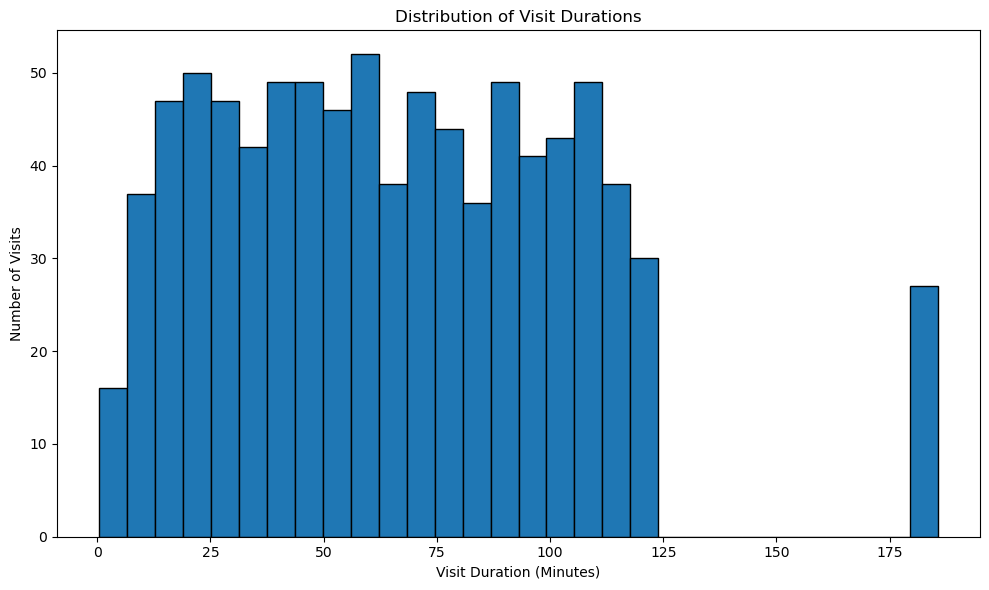

In [7]:
plt.figure(figsize=(10, 6))
plt.hist(visits['visit_duration_minutes'].dropna(), bins=30, edgecolor='black')
plt.title('Distribution of Visit Durations')
plt.xlabel('Visit Duration (Minutes)')
plt.ylabel('Number of Visits')
plt.tight_layout()
plt.savefig(plots_dir / 'visit_duration_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Core Question 1: Average Visit and Travel Duration Across Service Types

This section calculates average visit duration and average valid travel duration for each service type.

The output helps compare how different services vary in terms of time spent with patients and transition time between visits.

In [8]:
service_summary = (
    visits
    .groupby('service_type', dropna=False)
    .agg(
        total_visits=('visit_id', 'count'),
        avg_visit_duration=('visit_duration_minutes', 'mean'),
        median_visit_duration=('visit_duration_minutes', 'median'),
        avg_valid_travel_duration=('valid_travel_duration_minutes', 'mean'),
        median_valid_travel_duration=('valid_travel_duration_minutes', 'median'),
        valid_travel_records=('valid_travel_duration_minutes', 'count')
    )
    .reset_index()
    .sort_values('avg_visit_duration', ascending=False)
)

# Round duration columns for readability
duration_cols = [
    'avg_visit_duration',
    'median_visit_duration',
    'avg_valid_travel_duration',
    'median_valid_travel_duration'
]
service_summary[duration_cols] = service_summary[duration_cols].round(2)

service_summary

,service_type,total_visits,avg_visit_duration,median_visit_duration,avg_valid_travel_duration,median_valid_travel_duration,valid_travel_records
3,Wound Care,220,69.17,67.55,117.80,167.13,3
1,Medication Administration,236,68.36,64.03,124.65,129.34,10
2,Physical Therapy,213,65.20,65.07,120.31,127.93,8
0,General Check-up,209,61.56,57.00,119.09,116.08,8


### Visualisation: Average Visit Duration by Service Type

The bar chart ranks service types by average visit duration.

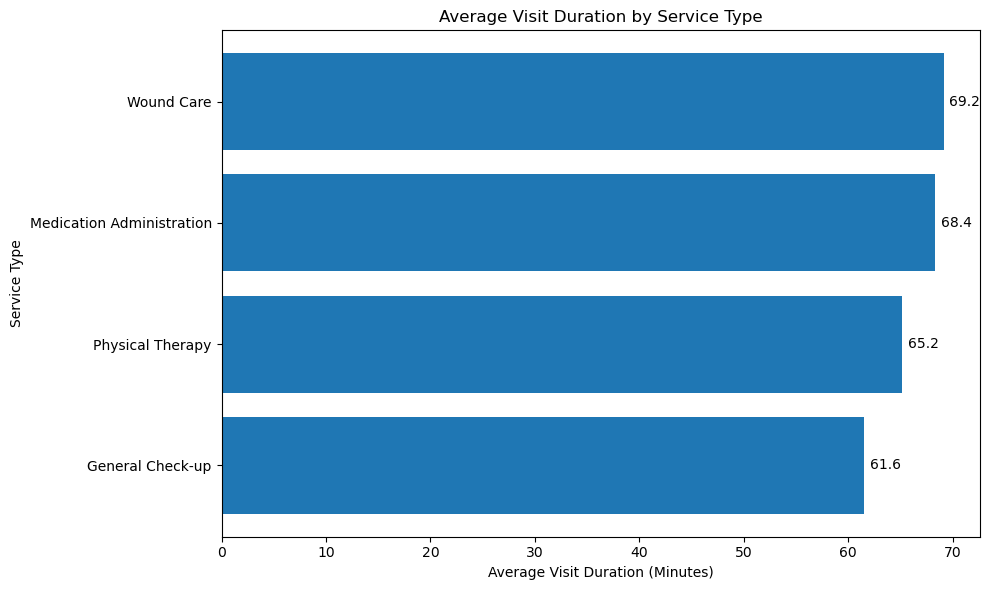

In [9]:
service_plot = service_summary.sort_values('avg_visit_duration', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(service_plot['service_type'], service_plot['avg_visit_duration'])
plt.title('Average Visit Duration by Service Type')
plt.xlabel('Average Visit Duration (Minutes)')
plt.ylabel('Service Type')

# Add values to bars
for index, value in enumerate(service_plot['avg_visit_duration']):
    plt.text(value + 0.5, index, f'{value:.1f}', va='center')

plt.tight_layout()
plt.savefig(plots_dir / 'avg_visit_duration_by_service_type.png', dpi=300, bbox_inches='tight')
plt.show()

### Visualisation: Average Valid Travel Duration by Service Type

This chart compares the filtered travel/transition duration across service types.

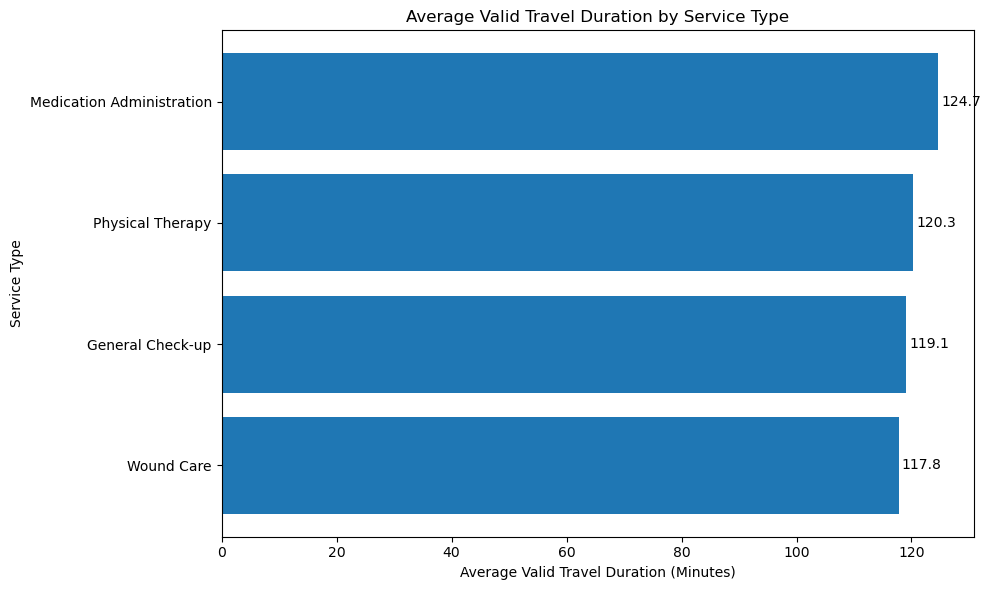

In [10]:
travel_service_plot = service_summary.dropna(subset=['avg_valid_travel_duration']).sort_values(
    'avg_valid_travel_duration', ascending=True
)

plt.figure(figsize=(10, 6))
plt.barh(travel_service_plot['service_type'], travel_service_plot['avg_valid_travel_duration'])
plt.title('Average Valid Travel Duration by Service Type')
plt.xlabel('Average Valid Travel Duration (Minutes)')
plt.ylabel('Service Type')

for index, value in enumerate(travel_service_plot['avg_valid_travel_duration']):
    plt.text(value + 0.5, index, f'{value:.1f}', va='center')

plt.tight_layout()
plt.savefig(plots_dir / 'avg_valid_travel_duration_by_service_type.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Core Question 2: Longest and Shortest Average Visit Duration by Service Type

This section identifies the service type with the longest average visit duration and the service type with the shortest average visit duration.

In [11]:
longest_service = service_summary.loc[service_summary['avg_visit_duration'].idxmax()]
shortest_service = service_summary.loc[service_summary['avg_visit_duration'].idxmin()]

print("Service Type with Longest Average Visit Duration")
print("------------------------------------------------")
print(f"Service Type: {longest_service['service_type']}")
print(f"Average Visit Duration: {longest_service['avg_visit_duration']:.2f} minutes")
print(f"Total Visits: {longest_service['total_visits']}")

print("\nService Type with Shortest Average Visit Duration")
print("------------------------------------------------")
print(f"Service Type: {shortest_service['service_type']}")
print(f"Average Visit Duration: {shortest_service['avg_visit_duration']:.2f} minutes")
print(f"Total Visits: {shortest_service['total_visits']}")

Service Type with Longest Average Visit Duration
------------------------------------------------
Service Type: Wound Care
Average Visit Duration: 69.17 minutes
Total Visits: 220

Service Type with Shortest Average Visit Duration
------------------------------------------------
Service Type: General Check-up
Average Visit Duration: 61.56 minutes
Total Visits: 209


## 11. Core Question 3: Visit Duration Differences Across Locations

This section investigates whether visit durations vary across different visit locations.

First, summary statistics are calculated by location. Then, a visual comparison is created using a bar chart and box plot.

In [12]:
location_summary = (
    visits
    .groupby('visit_location', dropna=False)
    .agg(
        total_visits=('visit_id', 'count'),
        avg_visit_duration=('visit_duration_minutes', 'mean'),
        median_visit_duration=('visit_duration_minutes', 'median'),
        std_visit_duration=('visit_duration_minutes', 'std'),
        avg_valid_travel_duration=('valid_travel_duration_minutes', 'mean')
    )
    .reset_index()
    .sort_values('avg_visit_duration', ascending=False)
)

location_summary[['avg_visit_duration', 'median_visit_duration', 'std_visit_duration', 'avg_valid_travel_duration']] = (
    location_summary[['avg_visit_duration', 'median_visit_duration', 'std_visit_duration', 'avg_valid_travel_duration']]
    .round(2)
)

location_summary

,visit_location,total_visits,avg_visit_duration,median_visit_duration,std_visit_duration,avg_valid_travel_duration
1,North,228,71.45,73.58,42.47,160.78
2,South,209,67.74,66.00,38.92,100.11
0,East,212,64.79,64.03,36.70,111.85
3,West,229,60.79,54.00,38.26,124.96


### Visualisation: Average Visit Duration by Location

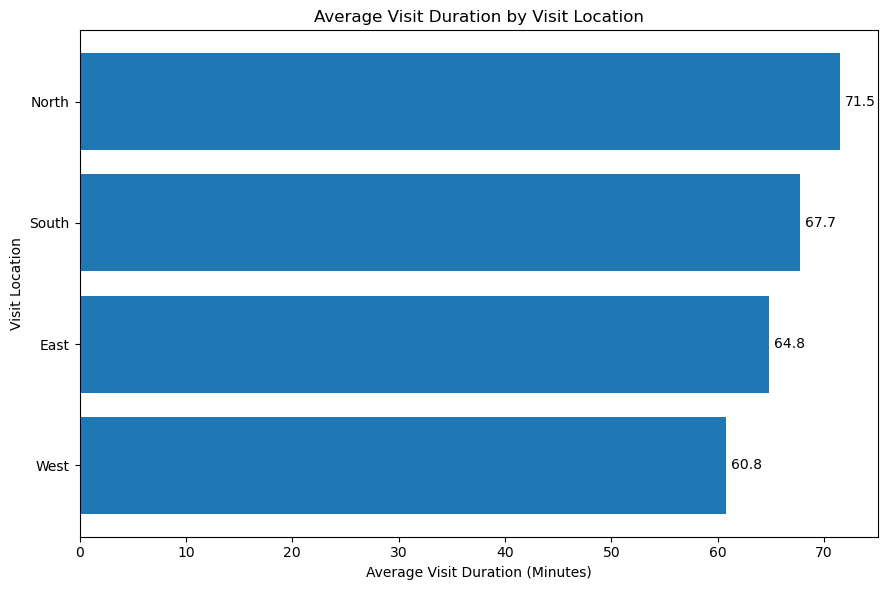

In [13]:
location_plot = location_summary.sort_values('avg_visit_duration', ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(location_plot['visit_location'], location_plot['avg_visit_duration'])
plt.title('Average Visit Duration by Visit Location')
plt.xlabel('Average Visit Duration (Minutes)')
plt.ylabel('Visit Location')

for index, value in enumerate(location_plot['avg_visit_duration']):
    plt.text(value + 0.5, index, f'{value:.1f}', va='center')

plt.tight_layout()
plt.savefig(plots_dir / 'avg_visit_duration_by_location.png', dpi=300, bbox_inches='tight')
plt.show()

### Visualisation: Box Plot of Visit Durations by Location

A box plot shows the spread of visit durations within each location, not just the average.

C:\Users\risha\AppData\Local\Temp\ipykernel_23716\4059837995.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=locations, patch_artist=True)


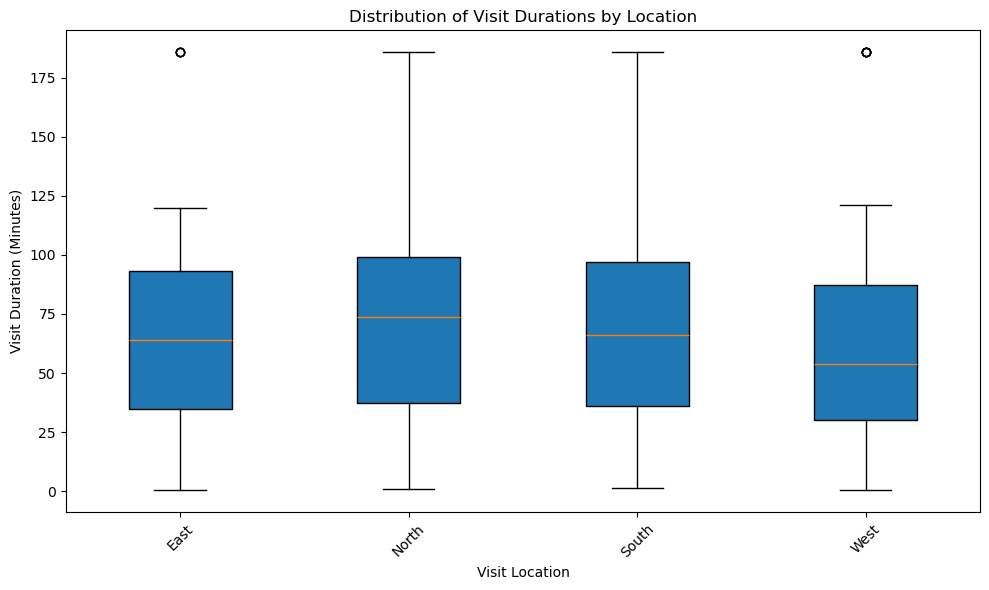

In [14]:
# Prepare data for box plot
locations = visits['visit_location'].dropna().unique()
boxplot_data = [
    visits.loc[visits['visit_location'] == location, 'visit_duration_minutes'].dropna()
    for location in locations
]

plt.figure(figsize=(10, 6))
plt.boxplot(boxplot_data, labels=locations, patch_artist=True)
plt.title('Distribution of Visit Durations by Location')
plt.xlabel('Visit Location')
plt.ylabel('Visit Duration (Minutes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(plots_dir / 'visit_duration_boxplot_by_location.png', dpi=300, bbox_inches='tight')
plt.show()

### Statistical Test: Difference in Visit Durations Across Locations

To assess whether visit durations differ meaningfully across locations, a one-way ANOVA test is conducted when SciPy is available.

- Null hypothesis: Average visit duration is the same across locations.
- Alternative hypothesis: At least one location has a different average visit duration.

A p-value below 0.05 suggests a statistically significant difference.

In [15]:
if SCIPY_AVAILABLE:
    groups = [
        visits.loc[visits['visit_location'] == location, 'visit_duration_minutes'].dropna()
        for location in visits['visit_location'].dropna().unique()
    ]

    # Only run ANOVA if there are at least two valid groups
    if len(groups) >= 2 and all(len(group) > 1 for group in groups):
        f_stat, p_value = stats.f_oneway(*groups)

        print("One-way ANOVA Test")
        print("------------------")
        print(f"F-statistic: {f_stat:.4f}")
        print(f"P-value: {p_value:.4f}")

        if p_value < 0.05:
            print("\nInterpretation: There is evidence of a statistically significant difference in visit durations across locations.")
        else:
            print("\nInterpretation: There is no strong evidence of a statistically significant difference in visit durations across locations.")
    else:
        print("ANOVA could not be performed because there are insufficient valid location groups.")
else:
    print("SciPy is not installed. Install scipy to run the ANOVA test:")
    print("!pip install scipy")

One-way ANOVA Test
------------------
F-statistic: 3.0155
P-value: 0.0292

Interpretation: There is evidence of a statistically significant difference in visit durations across locations.


## 12. Core Question 4: Top 3 and Bottom 3 Nurses by Average Travel Duration

This section identifies nurses with the highest and lowest average valid travel duration.

To avoid misleading results from nurses with very few valid travel records, a minimum count threshold is applied. (This may not be exactly accurate because we are taking into account only valid travel durations because we cannot estimate the actual travel durations of each nurse on the basis of the data provided)

In [16]:
# Minimum number of valid travel observations required for nurse ranking, made 0 because technicaly valid travel durations are lesser
minimum_travel_records = 0

nurse_travel_summary = (
    visits
    .groupby('nurse_id', dropna=False)
    .agg(
        total_visits=('visit_id', 'count'),
        valid_travel_records=('valid_travel_duration_minutes', 'count'),
        avg_valid_travel_duration=('valid_travel_duration_minutes', 'mean'),
        median_valid_travel_duration=('valid_travel_duration_minutes', 'median')
    )
    .reset_index()
)

# Keep nurses with sufficient valid travel records
nurse_travel_ranked = nurse_travel_summary[
    nurse_travel_summary['valid_travel_records'] >= minimum_travel_records
].copy()

nurse_travel_ranked[['avg_valid_travel_duration', 'median_valid_travel_duration']] = (
    nurse_travel_ranked[['avg_valid_travel_duration', 'median_valid_travel_duration']].round(2)
)

overall_avg_travel = visits['valid_travel_duration_minutes'].mean()

nurse_travel_ranked['difference_from_overall_avg'] = (
    nurse_travel_ranked['avg_valid_travel_duration'] - overall_avg_travel
).round(2)

top_3_nurses = nurse_travel_ranked.sort_values('avg_valid_travel_duration', ascending=False).head(3)
bottom_3_nurses = nurse_travel_ranked.sort_values('avg_valid_travel_duration', ascending=True).head(3)

print(f"Overall average valid travel duration: {overall_avg_travel:.2f} minutes")
print(f"Minimum valid travel records required: {minimum_travel_records}")

print("\nTop 3 Nurses by Average Valid Travel Duration")
display(top_3_nurses)

print("\nBottom 3 Nurses by Average Valid Travel Duration")
display(bottom_3_nurses)

Overall average valid travel duration: 121.21 minutes
Minimum valid travel records required: 0

Top 3 Nurses by Average Valid Travel Duration


,nurse_id,total_visits,valid_travel_records,avg_valid_travel_duration,median_valid_travel_duration,difference_from_overall_avg
94,N9783,9,1,225.9,225.9,104.69
73,N7802,7,1,200.0,200.0,78.79
16,N2044,12,1,198.0,198.0,76.79



Bottom 3 Nurses by Average Valid Travel Duration


,nurse_id,total_visits,valid_travel_records,avg_valid_travel_duration,median_valid_travel_duration,difference_from_overall_avg
77,N8068,6,1,12.12,12.12,-109.09
60,N6256,9,1,22.85,22.85,-98.36
5,N1415,8,1,33.65,33.65,-87.56


### Visualisation: Top and Bottom Nurses by Travel Duration

This chart combines the top 3 and bottom 3 nurses to show the difference in average travel/transition duration.

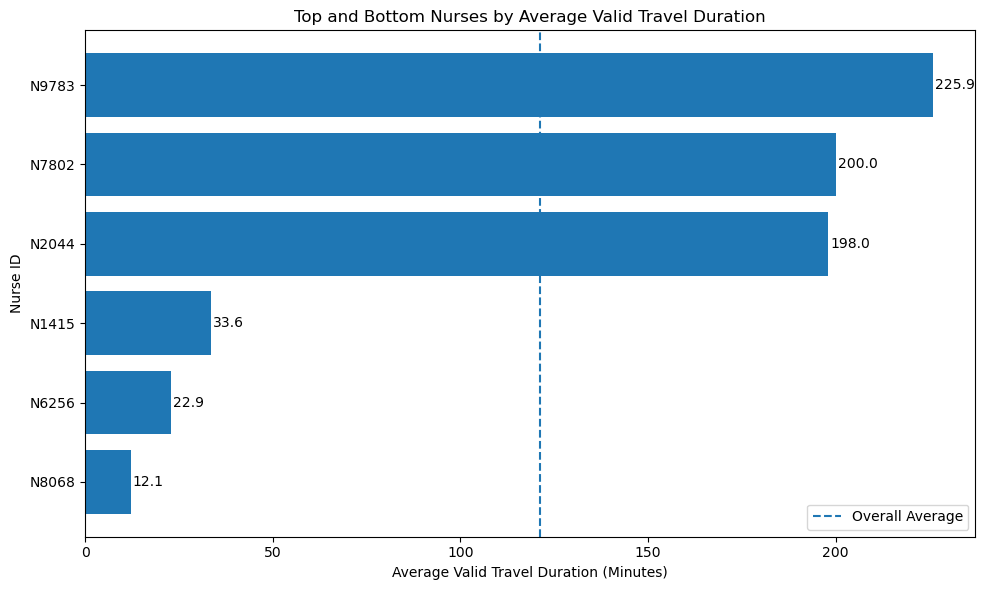

In [17]:
top_bottom_nurses = pd.concat([
    top_3_nurses.assign(group='Top 3 Longest'),
    bottom_3_nurses.assign(group='Bottom 3 Shortest')
])

top_bottom_nurses = top_bottom_nurses.sort_values('avg_valid_travel_duration', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_bottom_nurses['nurse_id'], top_bottom_nurses['avg_valid_travel_duration'])
plt.axvline(overall_avg_travel, linestyle='--', linewidth=1.5, label='Overall Average')
plt.title('Top and Bottom Nurses by Average Valid Travel Duration')
plt.xlabel('Average Valid Travel Duration (Minutes)')
plt.ylabel('Nurse ID')
plt.legend()

for index, value in enumerate(top_bottom_nurses['avg_valid_travel_duration']):
    plt.text(value + 0.5, index, f'{value:.1f}', va='center')

plt.tight_layout()
plt.savefig(plots_dir / 'top_bottom_nurses_travel_duration.png', dpi=300, bbox_inches='tight')
plt.show()

## 13. Core Question 5: Insights from Nurse Notes

This section analyses the processed nurse notes to identify patterns that may influence visit duration.

The processed dataset already contains binary note indicators and an outcome category. These fields are used to compare visit durations across different patient needs and visit outcomes.

In [18]:
# Identify note indicator columns
note_indicator_cols = [
    col for col in visits.columns
    if col.startswith('note_mentions_')
]

note_indicator_cols

['note_mentions_urgent',
 'note_mentions_follow_up',
 'note_mentions_pain',
 'note_mentions_weakness_or_dizziness',
 'note_mentions_stable_or_improving',
 'note_mentions_medication',
 'note_mentions_wound_care',
 'note_mentions_mobility_support']

### Nurse Note Keyword Frequency

This table shows how often each extracted keyword category appears in the nurse notes.

In [19]:
note_keyword_summary = (
    visits[note_indicator_cols]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

note_keyword_summary.columns = ['note_keyword_indicator', 'number_of_visits']
note_keyword_summary

,note_keyword_indicator,number_of_visits
0,note_mentions_follow_up,561
1,note_mentions_stable_or_improving,361
2,note_mentions_weakness_or_dizziness,333
3,note_mentions_wound_care,195
4,note_mentions_urgent,158
5,note_mentions_medication,156
6,note_mentions_pain,96
7,note_mentions_mobility_support,86


### Visit Duration by Nurse Note Outcome Category

This analysis compares average visit duration across note outcome categories.

In [20]:
if 'note_outcome_category' in visits.columns:
    outcome_duration_summary = (
        visits
        .groupby('note_outcome_category', dropna=False)
        .agg(
            total_visits=('visit_id', 'count'),
            avg_visit_duration=('visit_duration_minutes', 'mean'),
            median_visit_duration=('visit_duration_minutes', 'median'),
            avg_valid_travel_duration=('valid_travel_duration_minutes', 'mean')
        )
        .reset_index()
        .sort_values('avg_visit_duration', ascending=False)
    )

    outcome_duration_summary[['avg_visit_duration', 'median_visit_duration', 'avg_valid_travel_duration']] = (
        outcome_duration_summary[['avg_visit_duration', 'median_visit_duration', 'avg_valid_travel_duration']]
        .round(2)
    )

    outcome_duration_summary
else:
    print("note_outcome_category column not found in dataset.")

### Visualisation: Average Visit Duration by Nurse Note Outcome Category

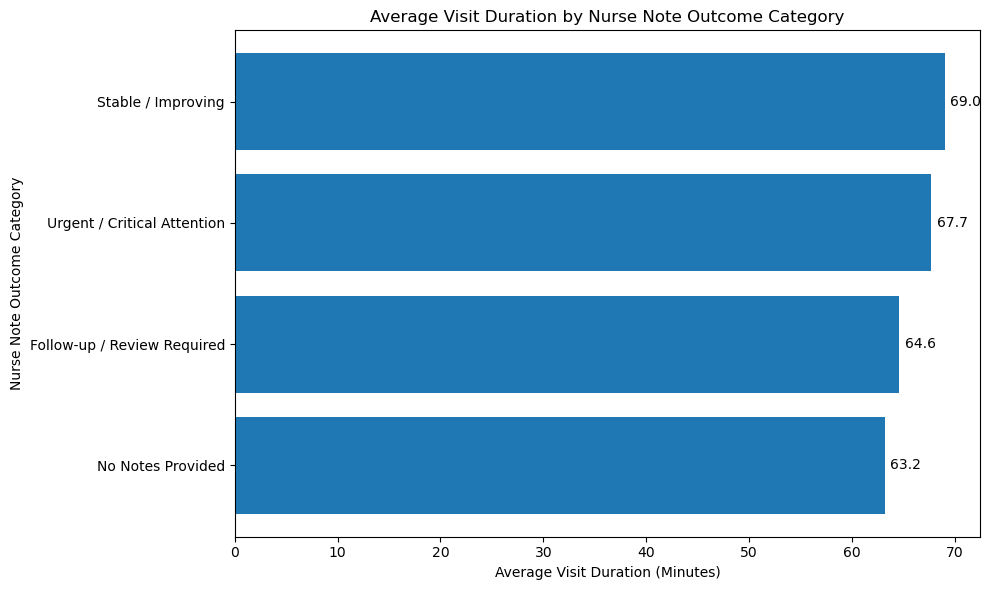

In [21]:
if 'note_outcome_category' in visits.columns:
    outcome_plot = outcome_duration_summary.sort_values('avg_visit_duration', ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(outcome_plot['note_outcome_category'], outcome_plot['avg_visit_duration'])
    plt.title('Average Visit Duration by Nurse Note Outcome Category')
    plt.xlabel('Average Visit Duration (Minutes)')
    plt.ylabel('Nurse Note Outcome Category')

    for index, value in enumerate(outcome_plot['avg_visit_duration']):
        plt.text(value + 0.5, index, f'{value:.1f}', va='center')

    plt.tight_layout()
    plt.savefig(plots_dir / 'avg_visit_duration_by_note_outcome.png', dpi=300, bbox_inches='tight')
    plt.show()

### Visit Duration Impact by Note Keyword

This section compares visits where each keyword indicator is present versus not present.

This helps identify whether certain patient needs are associated with longer visit durations.

In [22]:
keyword_impact_rows = []

for col in note_indicator_cols:
    present_mean = visits.loc[visits[col] == 1, 'visit_duration_minutes'].mean()
    absent_mean = visits.loc[visits[col] == 0, 'visit_duration_minutes'].mean()
    present_count = (visits[col] == 1).sum()
    absent_count = (visits[col] == 0).sum()

    keyword_impact_rows.append({
        "keyword_indicator": col,
        "visits_with_keyword": present_count,
        "visits_without_keyword": absent_count,
        "avg_duration_with_keyword": present_mean,
        "avg_duration_without_keyword": absent_mean,
        "difference_minutes": present_mean - absent_mean
    })

keyword_impact = pd.DataFrame(keyword_impact_rows)
keyword_impact = keyword_impact.sort_values('difference_minutes', ascending=False)

numeric_cols = [
    'avg_duration_with_keyword',
    'avg_duration_without_keyword',
    'difference_minutes'
]
keyword_impact[numeric_cols] = keyword_impact[numeric_cols].round(2)

keyword_impact

,keyword_indicator,visits_with_keyword,visits_without_keyword,avg_duration_with_keyword,avg_duration_without_keyword,difference_minutes
6,note_mentions_wound_care,195,683,70.57,64.93,5.65
4,note_mentions_stable_or_improving,361,517,67.50,65.26,2.24
0,note_mentions_urgent,158,720,67.73,65.84,1.90
3,note_mentions_weakness_or_dizziness,333,545,67.24,65.53,1.71
7,note_mentions_mobility_support,86,792,66.94,66.10,0.84
5,note_mentions_medication,156,722,66.26,66.16,0.10
1,note_mentions_follow_up,561,317,65.49,67.40,-1.91
2,note_mentions_pain,96,782,60.22,66.91,-6.69


### Visualisation: Keyword Impact on Visit Duration

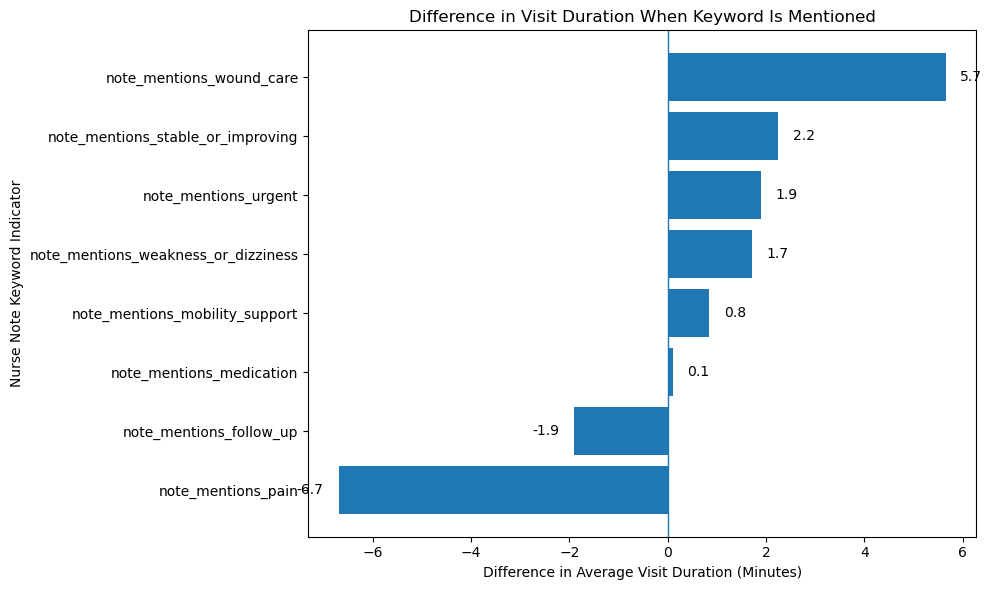

In [23]:
keyword_plot = keyword_impact.sort_values('difference_minutes', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(keyword_plot['keyword_indicator'], keyword_plot['difference_minutes'])
plt.axvline(0, linewidth=1)
plt.title('Difference in Visit Duration When Keyword Is Mentioned')
plt.xlabel('Difference in Average Visit Duration (Minutes)')
plt.ylabel('Nurse Note Keyword Indicator')

for index, value in enumerate(keyword_plot['difference_minutes']):
    label_position = value + 0.3 if value >= 0 else value - 0.3
    horizontal_alignment = 'left' if value >= 0 else 'right'
    plt.text(label_position, index, f'{value:.1f}', va='center', ha=horizontal_alignment)

plt.tight_layout()
plt.savefig(plots_dir / 'keyword_impact_on_visit_duration.png', dpi=300, bbox_inches='tight')
plt.show()

## 14. Additional Operational Analysis

The following analyses provide additional operational context that may support recommendations.

### Visits by Service Type

This shows the workload distribution across service types.

In [24]:
service_volume = (
    visits['service_type']
    .value_counts()
    .reset_index()
)

service_volume.columns = ['service_type', 'number_of_visits']
service_volume

,service_type,number_of_visits
0,Medication Administration,236
1,Wound Care,220
2,Physical Therapy,213
3,General Check-up,209


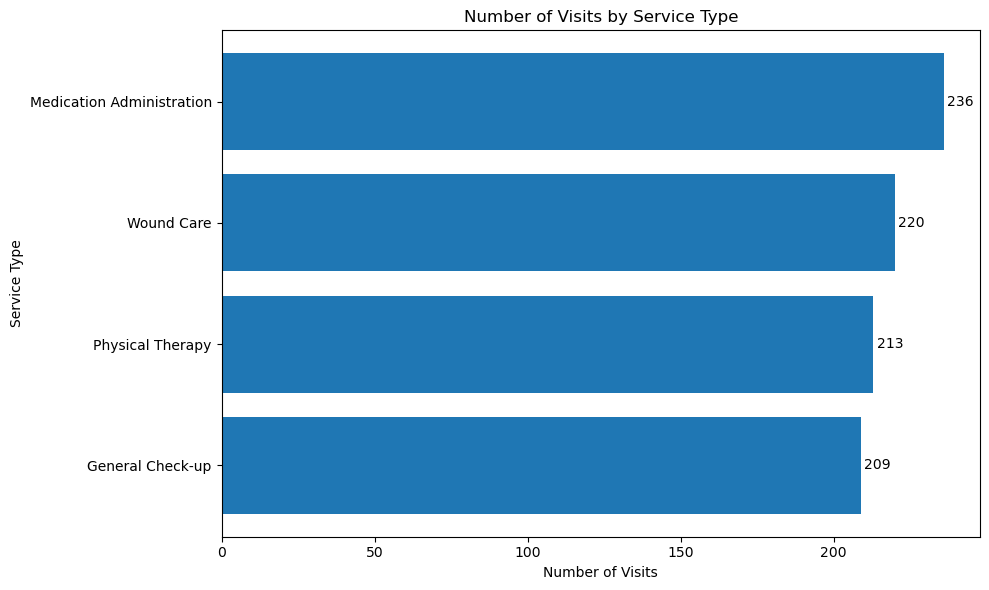

In [25]:
service_volume_plot = service_volume.sort_values('number_of_visits', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(service_volume_plot['service_type'], service_volume_plot['number_of_visits'])
plt.title('Number of Visits by Service Type')
plt.xlabel('Number of Visits')
plt.ylabel('Service Type')

for index, value in enumerate(service_volume_plot['number_of_visits']):
    plt.text(value + 1, index, str(value), va='center')

plt.tight_layout()
plt.savefig(plots_dir / 'number_of_visits_by_service_type.png', dpi=300, bbox_inches='tight')
plt.show()

### Service Type and Location Heatmap

This heatmap-style table shows average visit duration by both service type and location.

In [26]:
service_location_pivot = pd.pivot_table(
    visits,
    values='visit_duration_minutes',
    index='service_type',
    columns='visit_location',
    aggfunc='mean'
).round(2)

service_location_pivot

visit_location,East,North,South,West
service_type,,,,
General Check-up,58.31,71.61,62.21,53.20
Medication Administration,70.64,68.82,72.86,62.70
Physical Therapy,63.67,71.52,70.74,55.87
Wound Care,64.07,72.97,66.03,71.17


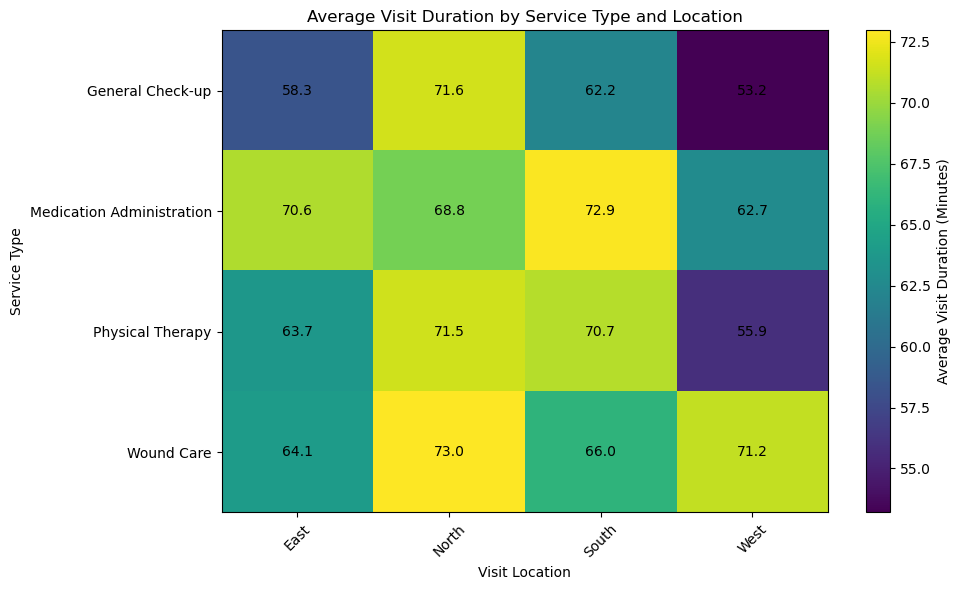

In [27]:
plt.figure(figsize=(10, 6))
plt.imshow(service_location_pivot, aspect='auto')
plt.colorbar(label='Average Visit Duration (Minutes)')
plt.title('Average Visit Duration by Service Type and Location')
plt.xlabel('Visit Location')
plt.ylabel('Service Type')
plt.xticks(range(len(service_location_pivot.columns)), service_location_pivot.columns, rotation=45)
plt.yticks(range(len(service_location_pivot.index)), service_location_pivot.index)

# Add values inside cells
for i in range(len(service_location_pivot.index)):
    for j in range(len(service_location_pivot.columns)):
        value = service_location_pivot.iloc[i, j]
        if not np.isnan(value):
            plt.text(j, i, f'{value:.1f}', ha='center', va='center')

plt.tight_layout()
plt.savefig(plots_dir / 'service_location_duration_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## 15. Core Question 6: Operational Efficiency Suggestions

The following code generates a concise set of data-driven recommendations based on the analysis results.

These recommendations should be refined in the final written report after reviewing the actual outputs.

In [28]:
# Extract key results for recommendation generation
highest_duration_service = longest_service['service_type']
highest_duration_service_avg = longest_service['avg_visit_duration']

lowest_duration_service = shortest_service['service_type']
lowest_duration_service_avg = shortest_service['avg_visit_duration']

highest_duration_location = location_summary.iloc[0]['visit_location']
highest_duration_location_avg = location_summary.iloc[0]['avg_visit_duration']

if len(top_3_nurses) > 0:
    highest_travel_nurse = top_3_nurses.iloc[0]['nurse_id']
    highest_travel_avg = top_3_nurses.iloc[0]['avg_valid_travel_duration']
else:
    highest_travel_nurse = "Not available"
    highest_travel_avg = np.nan

print("Operational Efficiency Suggestions")
print("-----------------------------------")

print(f"1. Service Scheduling:")
print(f"   {highest_duration_service} has the longest average visit duration at approximately {highest_duration_service_avg:.2f} minutes.")
print("   Longer scheduling slots should be considered for this service type to reduce delays and rushed visits.")

print(f"\n2. Shorter Service Slot Optimisation:")
print(f"   {lowest_duration_service} has the shortest average visit duration at approximately {lowest_duration_service_avg:.2f} minutes.")
print("   These shorter visits may be grouped more efficiently within nurse schedules.")

print(f"\n3. Location-Based Planning:")
print(f"   {highest_duration_location} has the highest average visit duration at approximately {highest_duration_location_avg:.2f} minutes.")
print("   The company should review whether this location has more complex patient cases, travel constraints, or operational delays.")

print(f"\n4. Nurse Routing:")
if highest_travel_nurse != "Not available":
    print(f"   Nurse {highest_travel_nurse} has one of the highest average valid travel durations at approximately {highest_travel_avg:.2f} minutes.")
    print("   This may indicate route inefficiency, location dispersion, or scheduling gaps.")
else:
    print("   There were insufficient valid travel records to identify high-travel nurses confidently.")

print("\n5. Nurse Notes and Patient Needs:")
print("   Visits mentioning urgent, pain-related, mobility, medication, or follow-up needs should be reviewed because these cases may require longer visit durations.")
print("   These indicators can support better appointment slot allocation and priority scheduling.")

print("\n6. Data Collection Improvement:")
print("   Actual travel logs, route distances, GPS coordinates, or nurse check-in/check-out data should be collected in future to measure travel duration more accurately.")

Operational Efficiency Suggestions
-----------------------------------
1. Service Scheduling:
   Wound Care has the longest average visit duration at approximately 69.17 minutes.
   Longer scheduling slots should be considered for this service type to reduce delays and rushed visits.

2. Shorter Service Slot Optimisation:
   General Check-up has the shortest average visit duration at approximately 61.56 minutes.
   These shorter visits may be grouped more efficiently within nurse schedules.

3. Location-Based Planning:
   North has the highest average visit duration at approximately 71.45 minutes.
   The company should review whether this location has more complex patient cases, travel constraints, or operational delays.

4. Nurse Routing:
   Nurse N9783 has one of the highest average valid travel durations at approximately 225.90 minutes.
   This may indicate route inefficiency, location dispersion, or scheduling gaps.

5. Nurse Notes and Patient Needs:
   Visits mentioning urgent, pa

## 16. Export Analysis Tables

The key analysis tables are exported as CSV files for use in the final report or README documentation.

In [29]:
# Create output folder for analysis tables
tables_dir = Path("analysis_tables")
tables_dir.mkdir(exist_ok=True)

# Export key tables
service_summary.to_csv(tables_dir / 'service_summary.csv', index=False)
location_summary.to_csv(tables_dir / 'location_summary.csv', index=False)
nurse_travel_ranked.to_csv(tables_dir / 'nurse_travel_summary.csv', index=False)

if 'outcome_duration_summary' in globals():
    outcome_duration_summary.to_csv(tables_dir / 'outcome_duration_summary.csv', index=False)

keyword_impact.to_csv(tables_dir / 'keyword_impact_summary.csv', index=False)
service_location_pivot.to_csv(tables_dir / 'service_location_duration_pivot.csv')

print("Analysis tables exported successfully.")
print(f"Tables saved in: {tables_dir.resolve()}")
print(f"Plots saved in: {plots_dir.resolve()}")

Analysis tables exported successfully.
Tables saved in: C:\Users\risha\Desktop\Speedoc Data Intern Assignment\GitHub Repository\LittleSteps_Assignment_SpeedocPteLtd_DataIntern\Data Analysis\analysis_tables
Plots saved in: C:\Users\risha\Desktop\Speedoc Data Intern Assignment\GitHub Repository\LittleSteps_Assignment_SpeedocPteLtd_DataIntern\Data Analysis\plots


## 17. Final Notes

This notebook completes the analysis required for the LittleSteps assignment.

The outputs generated here should be used to prepare the final report, including:
- Summary statistics
- Key visualisations
- Service-type findings
- Location-based findings
- Nurse travel findings
- Nurse-note insights
- Operational recommendations

After running all notebook cells, review the outputs carefully and use the strongest findings in the final report.